# Figure selection analysis (notebook version)

This notebook mirrors `analysis/make_fig_selection.py` and adds a direct comparison between:

- `evidence_llm/extracted_txt.json`
- `evidence_llm/extracted_txt_rerun.json`

All methods are evaluated against **text-sourced human annotations**.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fsize = 10
plt.rcParams.update({"font.size": fsize})


In [2]:
datasets = [
    "adipose_Emont2022",
    "adipose_Hildreth2021",
    "bone_He2021",
    "eye_Gautam2021",
    "lung_Adams2020",
    "ovary_Wagner2020",
    "testis_Shamis2020",
]
labels = {
    "adipose_Emont2022": "Adipose\n(Emont)",
    "adipose_Hildreth2021": "Adipose\n(Hildreth)",
    "bone_He2021": "Bone\n(He)",
    "eye_Gautam2021": "Eye\n(Gautam)",
    "lung_Adams2020": "Lung\n(Adams)",
    "ovary_Wagner2020": "Ovary\n(Wagner)",
    "testis_Shamis2020": "Testis\n(Shamis)",
}
short_labels = {
    "adipose_Emont2022": "Emont",
    "adipose_Hildreth2021": "Hildreth",
    "bone_He2021": "He",
    "eye_Gautam2021": "Gautam",
    "lung_Adams2020": "Adams",
    "ovary_Wagner2020": "Wagner",
    "testis_Shamis2020": "Shamis",
}
N_values = [10, 20, 30, 40, 50, 100, 200, 300, 400, 500]


In [3]:
def load_and_norm(path):
    df = pd.read_json(path)
    df["group_name"] = df["group_name"].str.strip().str.upper()
    df["feature_name"] = df["feature_name"].str.strip().str.upper()
    return df


def build_pairs(df, col="feature_id"):
    pairs = set()
    for _, r in df.iterrows():
        gn, fv = r.get("group_name"), r.get(col)
        if pd.notna(gn) and pd.notna(fv) and gn and fv:
            pairs.add((gn, fv))
    return pairs


def build_groups(df, col="feature_id"):
    groups = {}
    for _, r in df.iterrows():
        gn, fv = r.get("group_name"), r.get(col)
        if pd.notna(gn) and pd.notna(fv) and gn and fv:
            groups.setdefault(gn, set()).add(fv)
    return groups


def pair_metrics(pairs_a, pairs_b):
    if not pairs_a and not pairs_b:
        return 0, 0, 0
    tp = len(pairs_a & pairs_b)
    p = tp / len(pairs_a) if pairs_a else 0
    r = tp / len(pairs_b) if pairs_b else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return p, r, f


def per_celltype_gene_f1(groups_a, groups_b):
    shared = set(groups_a) & set(groups_b)
    if not shared:
        return 0, 0
    f1s = []
    for ct in shared:
        a, b = groups_a[ct], groups_b[ct]
        tp = len(a & b)
        p = tp / len(a) if a else 0
        r = tp / len(b) if b else 0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0
        f1s.append(f)
    return np.mean(f1s), len(shared)


def upper_bound_recall(hmn_pairs, deg_df, top_n):
    deg_top = deg_df[deg_df["metrics_rank"] <= top_n]
    deg_pairs = build_pairs(deg_top)
    if not hmn_pairs:
        return 0
    return len(hmn_pairs & deg_pairs) / len(hmn_pairs)


In [4]:
def compute_analysis(llm_filename="extracted_txt.json"):
    data = {}
    for ds in datasets:
        base = Path(f"../data/{ds}")
        hmn_all = load_and_norm(base / "evidence_human" / "extracted.json")
        hmn = hmn_all[hmn_all["source_type"] == "text"].copy()
        deg = load_and_norm(base / "evidence_deg" / "extracted.json")
        gen = load_and_norm(base / "evidence_generated" / "extracted.json")

        llm_path = base / "evidence_llm" / llm_filename
        if not llm_path.exists():
            llm_path = base / "evidence_llm" / "extracted_txt.json"
        llm = load_and_norm(llm_path)


        sel, sel_anon = {}, {}
        for n in N_values:
            p = base / "evidence_selected" / f"selected_top{n}.json"
            if p.exists():
                sel[n] = load_and_norm(p)
            pa = base / "evidence_selected" / f"selected_anon_top{n}.json"
            if pa.exists():
                sel_anon[n] = load_and_norm(pa)

        data[ds] = {
            "hmn": hmn,
            "deg": deg,
            "gen": gen,
            "llm": llm,
            "sel": sel,
            "sel_anon": sel_anon,
        }

    sweep_rows = []
    for ds in datasets:
        d = data[ds]
        hmn_pairs = build_pairs(d["hmn"])
        hmn_groups = build_groups(d["hmn"])
        for mode, sel_dict in [("named", d["sel"]), ("anon", d["sel_anon"])]:
            for n in N_values:
                if n not in sel_dict:
                    continue
                sel_pairs = build_pairs(sel_dict[n])
                sel_groups = build_groups(sel_dict[n])
                p_prec, p_rec, p_f1 = pair_metrics(sel_pairs, hmn_pairs)
                ct_f1, _ = per_celltype_gene_f1(sel_groups, hmn_groups)
                ub = upper_bound_recall(hmn_pairs, d["deg"], n)
                sweep_rows.append({
                    "dataset": ds,
                    "mode": mode,
                    "N": n,
                    "pair_precision": p_prec,
                    "pair_recall": p_rec,
                    "pair_f1": p_f1,
                    "gene_f1": ct_f1,
                    "upper_bound_recall": ub,
                })
    sweep = pd.DataFrame(sweep_rows)

    named = sweep[sweep["mode"] == "named"]
    best_named = named.loc[named.groupby("dataset")["pair_f1"].idxmax()]

    method_rows = []
    for ds in datasets:
        d = data[ds]
        hmn_pairs = build_pairs(d["hmn"])

        _, _, ext_f1 = pair_metrics(build_pairs(d["llm"]), hmn_pairs)
        _, _, gen_f1 = pair_metrics(build_pairs(d["gen"]), hmn_pairs)
        bn = best_named[best_named["dataset"] == ds].iloc[0]

        method_rows.append({
            "dataset": ds,
            "ext_pair_f1": ext_f1,
            "gen_pair_f1": gen_f1,
            "sel_pair_f1": bn["pair_f1"],
            "best_n": int(bn["N"]),
        })
    methods = pd.DataFrame(method_rows)

    ext_cost = 0
    gen_cost = 0
    sel_cost = 0

    for ds in datasets:
        mf = Path(f"../data/{ds}/evidence_llm/metrics.json")
        if mf.exists():
            m = json.load(open(mf))
            ext_cost += m.get("total_cost", 0)

        mf = Path(f"../data/{ds}/evidence_generated/metrics.json")
        if mf.exists():
            m = json.load(open(mf))
            gen_cost += m.get("total_cost", 0)

        best_n = int(methods.loc[methods["dataset"] == ds, "best_n"].iloc[0])
        mf = Path(f"../data/{ds}/evidence_selected/metrics_top{best_n}.json")
        if mf.exists():
            m = json.load(open(mf))
            sel_cost += m.get("total_cost", 0)

    return {
        "llm_filename": llm_filename,
        "sweep": sweep,
        "methods": methods,
        "best_named": best_named,
        "ext_cost": ext_cost,
        "gen_cost": gen_cost,
        "sel_cost": sel_cost,
    }


In [5]:
res_txt = compute_analysis("extracted_txt.json")
res_rerun = compute_analysis("extracted_txt_rerun.json")

summary = pd.DataFrame([
    {
        "run": "extracted_txt.json",
        "ext_mean_f1": res_txt["methods"]["ext_pair_f1"].mean(),
        "gen_mean_f1": res_txt["methods"]["gen_pair_f1"].mean(),
        "sel_mean_f1": res_txt["methods"]["sel_pair_f1"].mean(),
        "ext_cost_usd": res_txt["ext_cost"],
        "gen_cost_usd": res_txt["gen_cost"],
        "sel_cost_usd": res_txt["sel_cost"],
    },
    {
        "run": "extracted_txt_rerun.json",
        "ext_mean_f1": res_rerun["methods"]["ext_pair_f1"].mean(),
        "gen_mean_f1": res_rerun["methods"]["gen_pair_f1"].mean(),
        "sel_mean_f1": res_rerun["methods"]["sel_pair_f1"].mean(),
        "ext_cost_usd": res_rerun["ext_cost"],
        "gen_cost_usd": res_rerun["gen_cost"],
        "sel_cost_usd": res_rerun["sel_cost"],
    },
])
summary


,run,ext_mean_f1,gen_mean_f1,sel_mean_f1,ext_cost_usd,gen_cost_usd,sel_cost_usd
0,extracted_txt.json,0.673307,0.171734,0.160164,3.76557,2.296975,5.936215
1,extracted_txt_rerun.json,0.685363,0.171734,0.160164,3.76557,2.296975,5.936215


## Extraction run comparison (per dataset)

In [6]:
cmp = res_txt["methods"][["dataset", "ext_pair_f1"]].rename(columns={"ext_pair_f1": "ext_f1_txt"}).merge(
    res_rerun["methods"][["dataset", "ext_pair_f1"]].rename(columns={"ext_pair_f1": "ext_f1_rerun"}),
    on="dataset",
)
cmp["delta_rerun_minus_txt"] = cmp["ext_f1_rerun"] - cmp["ext_f1_txt"]
cmp


,dataset,ext_f1_txt,ext_f1_rerun,delta_rerun_minus_txt
0,adipose_Emont2022,0.625000,0.615385,-0.009615
1,adipose_Hildreth2021,0.774194,0.794118,0.019924
2,bone_He2021,0.446043,0.449275,0.003232
3,eye_Gautam2021,0.583333,0.619718,0.036385
4,lung_Adams2020,0.804878,0.825000,0.020122
5,ovary_Wagner2020,0.777778,0.788732,0.010955
6,testis_Shamis2020,0.701923,0.705314,0.003391


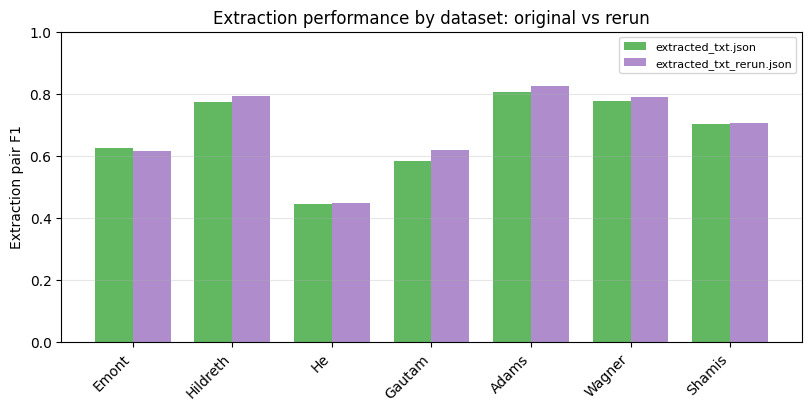

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
x = np.arange(len(datasets))
width = 0.38

cmp_idx = cmp.set_index("dataset")
vals_txt = [cmp_idx.loc[ds, "ext_f1_txt"] for ds in datasets]
vals_rerun = [cmp_idx.loc[ds, "ext_f1_rerun"] for ds in datasets]

ax.bar(x - width / 2, vals_txt, width, label="extracted_txt.json", color="tab:green", alpha=0.75)
ax.bar(x + width / 2, vals_rerun, width, label="extracted_txt_rerun.json", color="tab:purple", alpha=0.75)

ax.set_xticks(x)
ax.set_xticklabels([short_labels[ds] for ds in datasets], rotation=45, ha="right")
ax.set_ylabel("Extraction pair F1")
ax.set_title("Extraction performance by dataset: original vs rerun")
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis="y")
ax.legend(fontsize=8)
plt.show()


## Three-panel figure (same structure as `make_fig_selection.py`)

Set `active` to either run (`res_txt` or `res_rerun`).

In [8]:
def plot_three_panel(res, save=False, tag="txt"):
    sweep = res["sweep"]
    methods = res["methods"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

    ax = axes[0]
    named_mean = sweep[sweep["mode"] == "named"].groupby("N").mean(numeric_only=True).reset_index()
    anon_mean = sweep[sweep["mode"] == "anon"].groupby("N").mean(numeric_only=True).reset_index()

    ax.plot(named_mean["N"], named_mean["pair_f1"], "o-", color="tab:blue", label="Named", markersize=5, linewidth=1.5)
    ax.plot(anon_mean["N"], anon_mean["pair_f1"], "s-", color="tab:red", label="Anonymous", markersize=5, linewidth=1.5)
    ax.plot(named_mean["N"], named_mean["upper_bound_recall"], "^--", color="gray", alpha=0.6,
            label="Upper bound recall", markersize=5, linewidth=1)

    gen_mean_f1 = methods["gen_pair_f1"].mean()
    ext_mean_f1 = methods["ext_pair_f1"].mean()

    ax.axhline(gen_mean_f1, color="tab:orange", linestyle=":", linewidth=1.5,
               label=f"Generation (F1={gen_mean_f1:.2f})", alpha=0.8)
    ax.axhline(ext_mean_f1, color="tab:green", linestyle=":", linewidth=1.5,
               label=f"Extraction (F1={ext_mean_f1:.2f})", alpha=0.8)

    ax.set_xlabel("Top N DEGs per cell type")
    ax.set_ylabel("Pair F1")
    ax.set_title("(a) Selection performance vs. N")
    ax.set_xscale("log")
    ax.set_xticks(N_values)
    ax.set_xticklabels([str(n) for n in N_values], rotation=45)
    ax.set_ylim(0, 0.8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7.5, loc="upper left")

    ax = axes[1]
    x = np.arange(len(datasets))
    width = 0.25

    ax.bar(x - width, methods["ext_pair_f1"], width, label="Extraction", color="tab:green", alpha=0.85)
    ax.bar(x, methods["gen_pair_f1"], width, label="Generation", color="tab:orange", alpha=0.85)
    ax.bar(x + width, methods["sel_pair_f1"], width, label="Selection", color="tab:blue", alpha=0.85)

    ax.set_ylabel("Pair F1")
    ax.set_title("(b) Method comparison by dataset")
    ax.set_xticks(x)
    ax.set_xticklabels([short_labels[ds] for ds in datasets], rotation=45, ha="right")
    ax.set_ylim(0, 0.9)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(fontsize=8)

    ax = axes[2]
    method_summary = {
        "Extraction": {"f1": ext_mean_f1, "cost": res["ext_cost"]},
        "Generation": {"f1": gen_mean_f1, "cost": res["gen_cost"]},
        "Selection": {"f1": methods["sel_pair_f1"].mean(), "cost": res["sel_cost"]},
    }
    colors_map = {"Extraction": "tab:green", "Generation": "tab:orange", "Selection": "tab:blue"}

    for name, vals in method_summary.items():
        ax.scatter(vals["cost"], vals["f1"], s=150, color=colors_map[name],
                   label=name, zorder=5, edgecolors="black", linewidth=0.5)
        ax.annotate(name, (vals["cost"], vals["f1"]), textcoords="offset points", xytext=(8, -5), fontsize=9)

    for ds in datasets:
        row = methods[methods["dataset"] == ds].iloc[0]

        mf = Path(f"../data/{ds}/evidence_llm/metrics.json")
        if mf.exists():
            m = json.load(open(mf))
            ax.scatter(m["total_cost"], row["ext_pair_f1"], s=30, color="tab:green", alpha=0.4, zorder=3)

        mf = Path(f"../data/{ds}/evidence_generated/metrics.json")
        if mf.exists():
            m = json.load(open(mf))
            ax.scatter(m["total_cost"], row["gen_pair_f1"], s=30, color="tab:orange", alpha=0.4, zorder=3)

        best_n = int(row["best_n"])
        mf = Path(f"../data/{ds}/evidence_selected/metrics_top{best_n}.json")
        if mf.exists():
            m = json.load(open(mf))
            ax.scatter(m["total_cost"], row["sel_pair_f1"], s=30, color="tab:blue", alpha=0.4, zorder=3)

    ax.set_xlabel("Cost (USD, 7 datasets)")
    ax.set_ylabel("Mean pair F1")
    ax.set_title("(c) Performance vs. cost")
    ax.set_ylim(0, 0.8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    if save:
        out = Path("figures")
        out.mkdir(exist_ok=True)
        fig.savefig(out / f"fig_selection_sweep_{tag}.pdf", bbox_inches="tight", dpi=150)
        fig.savefig(out / f"fig_selection_sweep_{tag}.png", bbox_inches="tight", dpi=150)

    plt.show()

    print("Method summary")
    for name, vals in method_summary.items():
        print(f"  {name}: pair F1 = {vals['f1']:.3f}, cost = ${vals['cost']:.2f}")


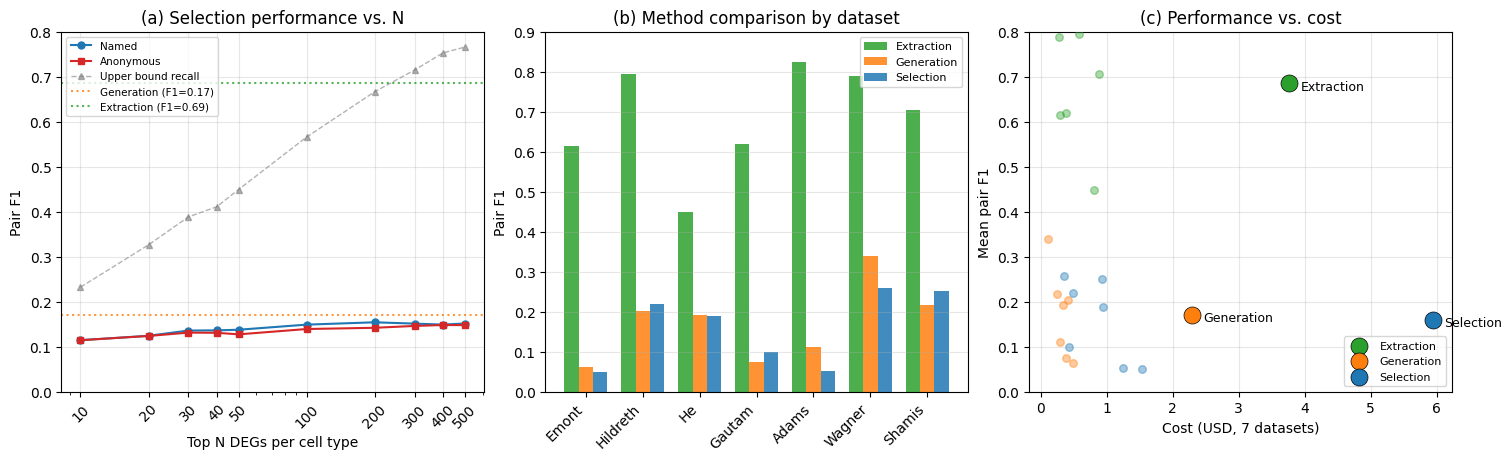

Method summary
  Extraction: pair F1 = 0.685, cost = $3.77
  Generation: pair F1 = 0.172, cost = $2.30
  Selection: pair F1 = 0.160, cost = $5.94


In [9]:
active = res_rerun  # choose res_txt or res_rerun
plot_three_panel(active, save=False, tag="rerun")
